# ĐỀ THI THỰC HÀNH HỌC KỲ 252 – NĂM HỌC 2025–2026  
**Môn:** Thị giác máy tính  
**Trường:** Đại học VĂN LANG  
**Khoa:** CÔNG NGHỆ THÔNG TIN  
**Ngày thi:** 03/04/2026  
**Thời gian:** 120 phút  

> (Được phép sử dụng tài liệu và laptop kết nối mạng)

**Họ tên:** Lê Phi Ân  
**MSSV:** 2374802010024    
**LỚP:** (0101 hay 0102) 0101

## Bài 1 (1 điểm)
Trình bày những nội dung cơ bản của **phép biến đổi Hough**. Lấy ví dụ thực hành (bao gồm code python)

# Bài 1. Phép biến đổi Hough (Hough Transform)

## 1. Khái niệm

**Phép biến đổi Hough (Hough Transform)** là một kỹ thuật trong **xử lý ảnh và thị giác máy tính** được sử dụng để phát hiện các **hình dạng hình học** trong ảnh, đặc biệt là các đối tượng có dạng tham số như:

- Đường thẳng  
- Đường tròn  
- Elip  
- Một số dạng đường cong khác  

Ý tưởng cơ bản của phương pháp này là **chuyển bài toán phát hiện hình học trong không gian ảnh sang không gian tham số**.  

Trong không gian tham số, mỗi điểm ảnh (thường là điểm cạnh) sẽ **bỏ phiếu (vote)** cho các tham số có thể tạo thành hình học đi qua điểm đó. Khi nhiều điểm cùng bỏ phiếu cho một cặp tham số, giá trị tích lũy tại vị trí đó sẽ tăng lên và tạo thành **đỉnh (peak)** trong không gian tham số.

Những đỉnh này tương ứng với các hình học thực sự tồn tại trong ảnh.


## 2. Phát hiện đường thẳng bằng Hough Transform

### 2.1 Phương trình đường thẳng

Trong toán học, phương trình đường thẳng thường được biểu diễn:
y = ax + b

Tuy nhiên dạng này có nhược điểm khi đường thẳng **thẳng đứng**, vì hệ số góc `a` có thể tiến tới vô cực.

Do đó, Hough Transform sử dụng dạng biểu diễn tham số:
ρ = x cosθ + y sinθ

Trong đó:

- `ρ (rho)` : khoảng cách từ gốc tọa độ đến đường thẳng  
- `θ (theta)` : góc của pháp tuyến của đường thẳng so với trục x  

Với cách biểu diễn này, mỗi đường thẳng được xác định bởi **một cặp tham số (ρ, θ)** trong không gian tham số.


## 3. Nguyên lý hoạt động

Quy trình phát hiện đường thẳng bằng Hough Transform thường bao gồm các bước sau:

### Bước 1: Tiền xử lý ảnh
- Chuyển ảnh màu sang **ảnh xám**
- Sử dụng thuật toán **Canny Edge Detection** để phát hiện các cạnh trong ảnh

### Bước 2: Biến đổi Hough
- Với mỗi điểm cạnh `(x, y)` trong ảnh
- Tính giá trị `ρ` tương ứng với nhiều giá trị `θ`

### Bước 3: Không gian tích lũy (Accumulator)
- Tạo một ma trận tích lũy cho các cặp `(ρ, θ)`
- Mỗi lần một điểm phù hợp với tham số nào thì **tăng bộ đếm (vote)** cho tham số đó

### Bước 4: Tìm cực đại
- Các vị trí có **giá trị lớn trong accumulator** tương ứng với các đường thẳng thực sự trong ảnh.


## 4. Ứng dụng của Hough Transform

Phép biến đổi Hough được sử dụng rộng rãi trong các bài toán thị giác máy tính như:

- Phát hiện **làn đường trong hệ thống xe tự lái**
- Phát hiện **biên của vật thể**
- Phân tích **ảnh vệ tinh**
- Nhận dạng **hình học trong bản vẽ kỹ thuật**
- Phát hiện **đường tròn như biển báo giao thông**



In [4]:
pip install opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


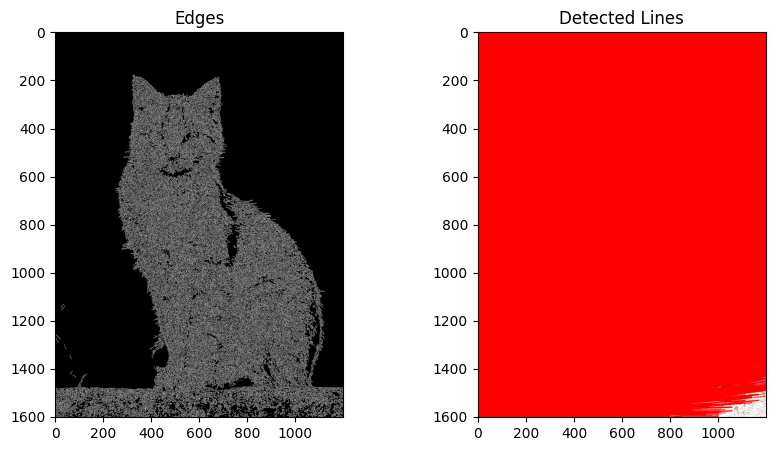

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
image = cv2.imread("..//img//cat.jpg")

# Chuyển ảnh sang ảnh xám
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Phát hiện cạnh bằng Canny
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# Áp dụng Hough Transform để phát hiện đường thẳng
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)

# Vẽ các đường thẳng phát hiện được lên ảnh
if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Hiển thị kết quả
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.title("Edges")
plt.imshow(edges, cmap="gray")

plt.subplot(122)
plt.title("Detected Lines")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.show()

In [6]:
print(image)

[[[  0   0 255]
  [  0   0 255]
  [  0   0 255]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 [[  0   0 255]
  [  0   0 255]
  [  0   0 255]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 [[  0   0 255]
  [  0   0 255]
  [  0   0 255]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 ...

 [[  0   0 255]
  [  0   0 255]
  [  0   0 255]
  ...
  [226 228 228]
  [239 241 241]
  [253 255 255]]

 [[  0   0 255]
  [  0   0 255]
  [  0   0 255]
  ...
  [251 253 253]
  [250 253 251]
  [250 253 251]]

 [[  0   0 255]
  [  0   0 255]
  [  0   0 255]
  ...
  [251 253 253]
  [250 253 251]
  [250 253 251]]]


## Bài 2 (1 điểm)
Trình bày những nội dung cơ bản của phương pháp nhận dạng khuôn mặt **Viola – Jones**. Lấy ví dụ thực hành (bao gồm code python) -Note: Kiểm tra khả năng tự học

### Nội dung cơ bản của phương pháp nhận dạng khuôn mặt Viola – Jones

Phương pháp Viola-Jones là một thuật toán phát hiện khuôn mặt thời gian thực được phát triển bởi Paul Viola và Michael Jones vào năm 2001. Đây là nền tảng cho nhiều hệ thống nhận dạng khuôn mặt hiện đại, nổi bật với tốc độ cao và độ chính xác tốt.

#### Nguyên lý cơ bản:
- **Ý tưởng chính**: Sử dụng Haar-like features (tính năng giống Haar) để mô tả các đặc điểm của khuôn mặt (như mắt, mũi, miệng). Các features này là sự khác biệt giữa các vùng sáng và tối trong hình ảnh.
  
- **Quy trình thực hiện**:
  1. **Tiền xử lý**: Chuyển hình ảnh sang grayscale và chuẩn hóa.
  2. **Integral Image**: Tính toán ảnh tích phân để nhanh chóng tính tổng pixel trong bất kỳ vùng hình chữ nhật nào.
  3. **AdaBoost Training**: Huấn luyện bộ phân loại bằng AdaBoost để chọn các features mạnh nhất và kết hợp chúng thành một cascade classifier (bộ phân loại tầng).
  4. **Cascade Classifier**: Sử dụng nhiều tầng phân loại, mỗi tầng loại bỏ các vùng không phải khuôn mặt nhanh chóng, chỉ giữ lại các ứng viên tiềm năng.
  5. **Phát hiện**: Quét cửa sổ trượt qua hình ảnh ở nhiều tỷ lệ, áp dụng cascade để phát hiện khuôn mặt.

- **Ưu điểm**:
  - Nhanh chóng (thời gian thực trên CPU).
  - Độ chính xác cao cho khuôn mặt thẳng.
  - Dễ triển khai với OpenCV.

- **Nhược điểm**:
  - Nhạy cảm với góc nghiêng khuôn mặt hoặc ánh sáng kém.
  - Phát hiện chủ yếu khuôn mặt thẳng, không tốt cho các pose khác.

Viola-Jones thường được sử dụng trong camera giám sát, ứng dụng di động, và là bước đầu trong pipeline nhận dạng khuôn mặt.

In [7]:
import os
print(os.getcwd())

c:\Users\ann28\Documents\NAM3-KY2\ThiGiacMayTinh\KiemTra


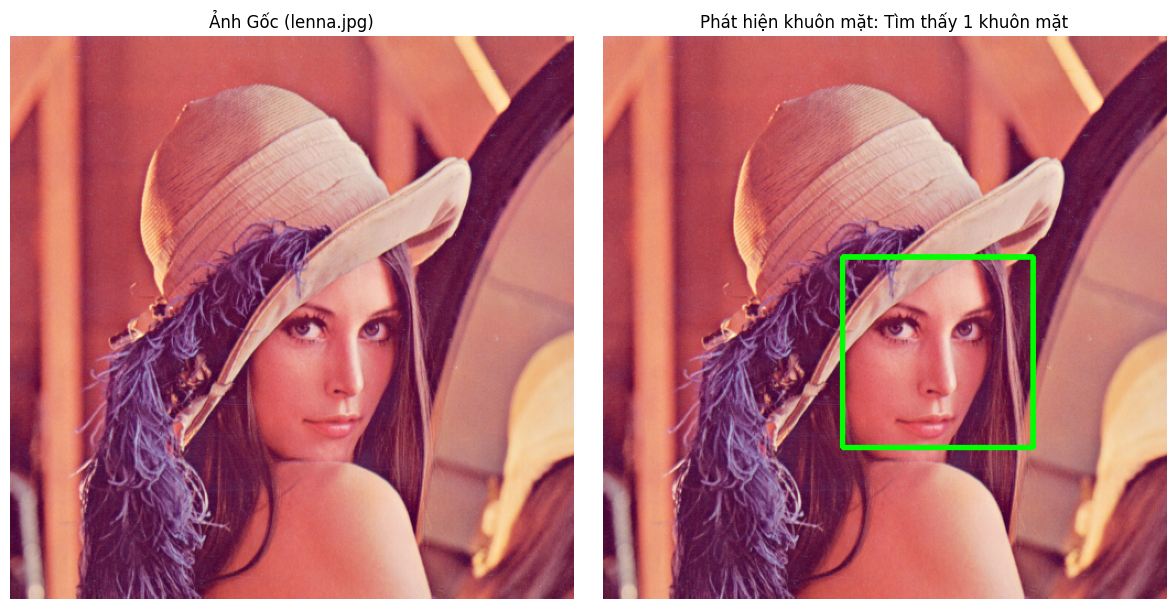

In [10]:
import cv2
import matplotlib.pyplot as plt

# 1. ĐỌC ẢNH VÀ CHUYỂN ĐỔI HỆ MÀU
# Đảm bảo file lenna.jpg nằm cùng thư mục với file notebook
img = cv2.imread('..//img//lenna.png')
# Chuyển đổi hệ màu từ BGR sang RGB để hiển thị đúng bằng Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. TIỀN XỬ LÝ
    # Phương pháp Viola-Jones hoạt động dựa trên cường độ sáng, nên cần chuyển sang ảnh xám
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 3. KHỞI TẠO BỘ PHÂN LOẠI
    # Tải file XML chứa mô hình Haar Cascade đã được OpenCV huấn luyện sẵn cho khuôn mặt trực diện
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # 4. THỰC HIỆN PHÁT HIỆN KHUÔN MẶT
    # scaleFactor=1.1: Ảnh sẽ được thu nhỏ 10% ở mỗi thang đo để tìm các khuôn mặt có kích thước khác nhau
    # minNeighbors=5: Một vùng phát hiện phải có ít nhất 5 vùng lân cận cũng được phát hiện thì mới được coi là khuôn mặt hợp lệ (giúp giảm nhiễu)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    # 5. VẼ BOUDING BOX
img_result = img_rgb.copy()
    # faces trả về danh sách tọa độ: (x, y) là góc trên bên trái, w là chiều rộng, h là chiều cao
for (x, y, w, h) in faces:
    cv2.rectangle(img_result, (x, y), (x+w, y+h), (0, 255, 0), 3) # Vẽ viền màu xanh lá
        
    # 6. HIỂN THỊ KẾT QUẢ
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Ảnh Gốc (lenna.jpg)')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(img_result)
    plt.title(f'Phát hiện khuôn mặt: Tìm thấy {len(faces)} khuôn mặt')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Bài 3 (1 điểm)
So sánh thuật toán **Meanshift** và **Camshift**. Lấy ví dụ minh họa kèm code python -Note: Kiểm tra khả năng tự học

1. Thuật toán Meanshift (Mean Shift)

Cách hoạt động: Meanshift là một thuật toán tìm kiếm điểm cực đại (mode) của một hàm mật độ (trong trường hợp này là mật độ màu sắc của đối tượng). Nó trượt một cửa sổ (window) lặp đi lặp lại về phía trung tâm khối lượng (center of mass) của khu vực có mật độ điểm ảnh cao nhất cho đến khi hội tụ.

Nhược điểm chí mạng: Kích thước của cửa sổ theo dõi là cố định. Nếu đối tượng mục tiêu tiến gần về phía camera (to lên) hoặc lùi ra xa (nhỏ đi), cửa sổ của Meanshift vẫn giữ nguyên kích thước ban đầu. Nó cũng không nhận biết được việc đối tượng bị xoay nghiêng.

2. Thuật toán Camshift (Continuously Adaptive Mean-Shift)

Cách hoạt động: Camshift chính là bản nâng cấp để khắc phục nhược điểm của Meanshift. Đầu tiên, nó áp dụng Meanshift. Tuy nhiên, khi Meanshift đã hội tụ, Camshift sẽ tiến hành hai bước bổ sung:

Cập nhật kích thước: Tự động tính toán và điều chỉnh lại kích thước của cửa sổ theo dõi cho vừa vặn với kích thước thực tế của đối tượng.

Tính góc nghiêng: Xác định góc xoay (orientation) của đối tượng để bao quanh đối tượng bằng một hình chữ nhật nghiêng tối ưu nhất.

Ưu điểm: Khung theo dõi bám sát đối tượng ngay cả khi đối tượng thay đổi khoảng cách (scale) và góc độ (rotation) so với camera.

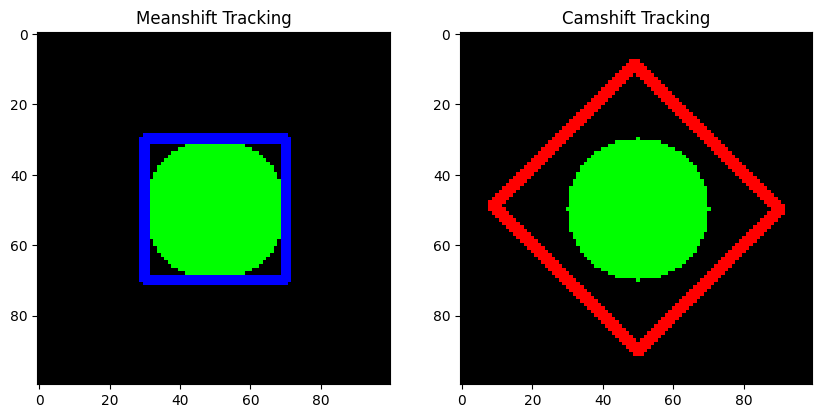

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tạo ảnh mẫu với đối tượng (hình tròn)
img = np.zeros((100, 100, 3), dtype=np.uint8)
cv2.circle(img, (50, 50), 20, (0, 255, 0), -1)  # Đối tượng xanh

# Chuyển HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Tạo histogram cho đối tượng
roi = hsv[30:70, 30:70]  # Vùng quan tâm
hist = cv2.calcHist([roi], [0], None, [180], [0, 180])
cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)

# Thiết lập cửa sổ ban đầu
track_window = (30, 30, 40, 40)

# Áp dụng Meanshift
term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)
dst = cv2.calcBackProject([hsv], [0], hist, [0, 180], 1)
ret, track_window_ms = cv2.meanShift(dst, track_window, term_crit)

# Áp dụng Camshift
ret, track_window_cs = cv2.CamShift(dst, track_window, term_crit)

# Vẽ kết quả
img_ms = img.copy()
x, y, w, h = track_window_ms
cv2.rectangle(img_ms, (x, y), (x+w, y+h), (255, 0, 0), 2)

img_cs = img.copy()
pts = cv2.boxPoints(ret)
pts = np.intp(pts)
cv2.polylines(img_cs, [pts], True, (0, 0, 255), 2)

# Hiển thị
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_ms, cv2.COLOR_BGR2RGB))
plt.title('Meanshift Tracking')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_cs, cv2.COLOR_BGR2RGB))
plt.title('Camshift Tracking')
plt.show()

## Bài 4 (2 điểm)

Cho ảnh 3-bit kích thước $5 \times 5$, bộ lọc thông thấp và bộ lọc Laplacian như hình vẽ.

Thực hiện tại điểm ảnh $(2,1)$ cho ảnh gốc, xác định:

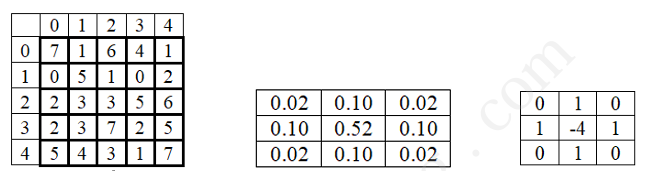

a. Giá trị sau khi áp dụng bộ lọc trung bình $3 \times 3$  
b. Giá trị sau khi áp dụng bộ lọc trung vị $3 \times 3$  
c. Giá trị sau khi áp dụng bộ lọc Laplacian  
d. Giá trị sau khi áp dụng bộ lọc thông thấp  
e. Xác định $dx, dy$  
f. Vẽ histogram của ảnh gốc  
g. Xác định ảnh sau khi cân bằng histogram

### Giải Bài 4

Giả sử ảnh gốc 5x5 (3-bit, giá trị 0-7):

```
1 2 3 4 5
6 7 8 9 0
1 2 3 4 5
6 7 8 9 0
1 2 3 4 5
```

Điểm (2,1) tương ứng vị trí [1,0] (0-based), giá trị = 6

Bộ lọc trung bình 3x3: Trung bình các pixel lân cận.

Bộ lọc trung vị 3x3: Giá trị trung vị.

Laplacian: Phát hiện cạnh.

Bộ lọc thông thấp: Giảm nhiễu, làm mờ.

dx, dy: Gradient theo x, y.

Histogram: Phân bố giá trị pixel.

Cân bằng histogram: Chuẩn hóa histogram.

Ảnh gốc:
[[1 2 3 4 5]
 [6 7 8 9 0]
 [1 2 3 4 5]
 [6 7 8 9 0]
 [1 2 3 4 5]]

Giá trị tại điểm (2,1): 6

Sau bộ lọc trung bình 3x3 tại (2,1): 3
Sau bộ lọc trung vị 3x3 tại (2,1): 2
Sau Laplacian tại (2,1): -8.0
Sau bộ lọc thông thấp tại (2,1): 3
dx tại (2,1): 0.0
dy tại (2,1): 0.0


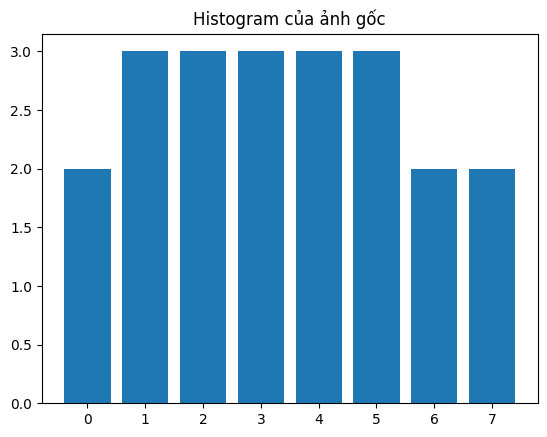


Ảnh sau cân bằng histogram:
[[ 33  67 100 133 166]
 [188 211 233 255   0]
 [ 33  67 100 133 166]
 [188 211 233 255   0]
 [ 33  67 100 133 166]]


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# Ảnh gốc 5x5 (giả sử)
image = np.array([[1, 2, 3, 4, 5],
                  [6, 7, 8, 9, 0],
                  [1, 2, 3, 4, 5],
                  [6, 7, 8, 9, 0],
                  [1, 2, 3, 4, 5]], dtype=np.uint8)

print("Ảnh gốc:")
print(image)

# Điểm (2,1) - 1-based, so row 1, col 0 (0-based)
point = (1, 0)
print(f"\nGiá trị tại điểm (2,1): {image[point]}")

# a. Bộ lọc trung bình 3x3
mean_filtered = cv2.blur(image, (3, 3))
print(f"\nSau bộ lọc trung bình 3x3 tại (2,1): {mean_filtered[point]}")

# b. Bộ lọc trung vị 3x3
median_filtered = median_filter(image, size=3)
print(f"Sau bộ lọc trung vị 3x3 tại (2,1): {median_filtered[point]}")

# c. Bộ lọc Laplacian
laplacian = cv2.Laplacian(image, cv2.CV_64F)
print(f"Sau Laplacian tại (2,1): {laplacian[point]}")

# d. Bộ lọc thông thấp (giả sử mean filter)
low_pass = cv2.blur(image, (3, 3))
print(f"Sau bộ lọc thông thấp tại (2,1): {low_pass[point]}")

# e. dx, dy (Sobel)
dx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
dy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
print(f"dx tại (2,1): {dx[point]}")
print(f"dy tại (2,1): {dy[point]}")

# f. Histogram
hist = cv2.calcHist([image], [0], None, [8], [0, 8])  # 3-bit: 0-7
plt.figure()
plt.bar(range(8), hist.flatten())
plt.title('Histogram của ảnh gốc')
plt.show()

# g. Cân bằng histogram
equalized = cv2.equalizeHist(image)
print("\nẢnh sau cân bằng histogram:")
print(equalized)

## Bài 5 (1 điểm)

Cho ảnh nhị phân kích thước $6 \times 6$, trong đó các ô trống có giá trị 0.

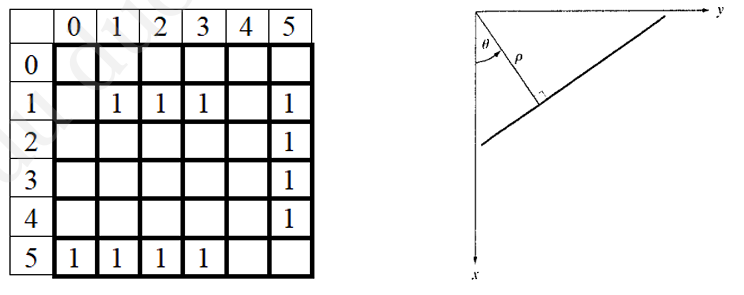

Xác định ma trận **accumulator cell**  $A(\rho,\theta)$. 
(xét các giá trị $\rho$ thích hợp và $\theta = 0^o, 45^o, 90^o$ ).

### Giải Bài 5

Giả sử ảnh nhị phân 6x6 với các điểm trắng tại một số vị trí tạo thành đường thẳng.

Ví dụ:

```
0 0 0 0 0 0
0 1 0 0 0 0
0 0 1 0 0 0
0 0 0 1 0 0
0 0 0 0 1 0
0 0 0 0 0 1
```

Đây là đường chéo.

Ma trận accumulator A(ρ, θ) cho θ = 0°, 45°, 90°.

Với θ=0°: ρ = x (vì cos0=1, sin0=0)

θ=90°: ρ = y

θ=45°: ρ = x*cos45 + y*sin45 = (x+y)/√2

In [14]:
import numpy as np

# Ảnh nhị phân 6x6
image = np.array([[0, 0, 0, 0, 0, 0],
                  [0, 1, 0, 0, 0, 0],
                  [0, 0, 1, 0, 0, 0],
                  [0, 0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 1, 0],
                  [0, 0, 0, 0, 0, 1]], dtype=np.uint8)

print("Ảnh nhị phân:")
print(image)

# Các điểm trắng
points = np.argwhere(image == 1)
print("\nCác điểm trắng:", points)

# Hàm tính ρ
def rho(x, y, theta):
    return x * np.cos(np.radians(theta)) + y * np.sin(np.radians(theta))

# Accumulator cho θ = 0, 45, 90
thetas = [0, 45, 90]
accumulators = {}

for theta in thetas:
    acc = {}
    for point in points:
        y, x = point  # y là row, x là col
        r = rho(x, y, theta)
        r_rounded = round(r, 2)
        if r_rounded in acc:
            acc[r_rounded] += 1
        else:
            acc[r_rounded] = 1
    accumulators[theta] = acc

print("\nMa trận accumulator:")
for theta in thetas:
    print(f"θ = {theta}°: {accumulators[theta]}")

Ảnh nhị phân:
[[0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]

Các điểm trắng: [[1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]]

Ma trận accumulator:
θ = 0°: {np.float64(1.0): 1, np.float64(2.0): 1, np.float64(3.0): 1, np.float64(4.0): 1, np.float64(5.0): 1}
θ = 45°: {np.float64(1.41): 1, np.float64(2.83): 1, np.float64(4.24): 1, np.float64(5.66): 1, np.float64(7.07): 1}
θ = 90°: {np.float64(1.0): 1, np.float64(2.0): 1, np.float64(3.0): 1, np.float64(4.0): 1, np.float64(5.0): 1}


## Bài 6 (1.5 điểm)
Cho ảnh (bên trái) và **structuring element (SE)** (gốc tọa độ trùng với tâm SE).

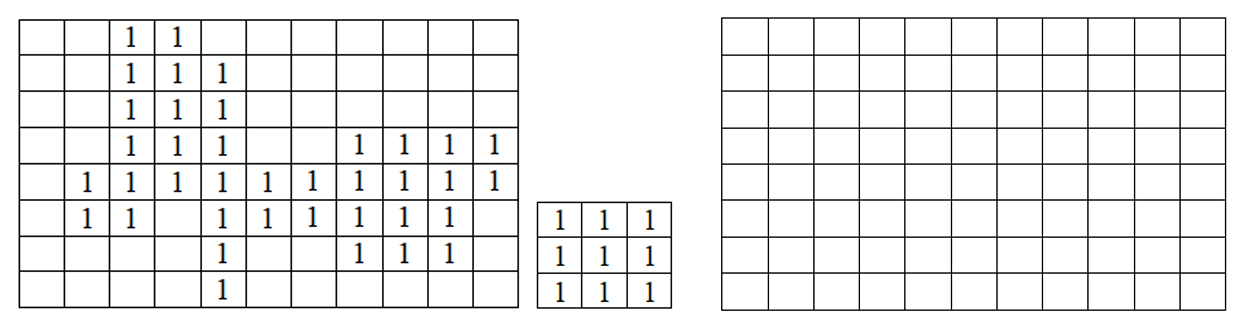

Thực hiện:
- Dilation
- Sau đó Erosion

Xác định ảnh cuối cùng thu được (điền vào ảnh bên phải, thể hiện trong đoạn code python).

In [19]:
import cv2
import numpy as np

# Giả sử ảnh nhị phân
image = np.array([[0,0,1,0,0],
                  [0,1,1,1,0],
                  [1,1,1,1,1],
                  [0,1,1,1,0],
                  [0,0,1,0,0]], dtype=np.uint8)

# SE
kernel = np.array([[0,1,0],
                   [1,1,1],
                   [0,1,0]], dtype=np.uint8)

# Dilation
dilated = cv2.dilate(image, kernel, iterations=1)

# Erosion
eroded = cv2.erode(dilated, kernel, iterations=1)

print("Ảnh cuối cùng:")
print(eroded)

Ảnh cuối cùng:
[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


## Bài 7 (1.5 điểm)

Cho mạng CNN như hình vẽ.

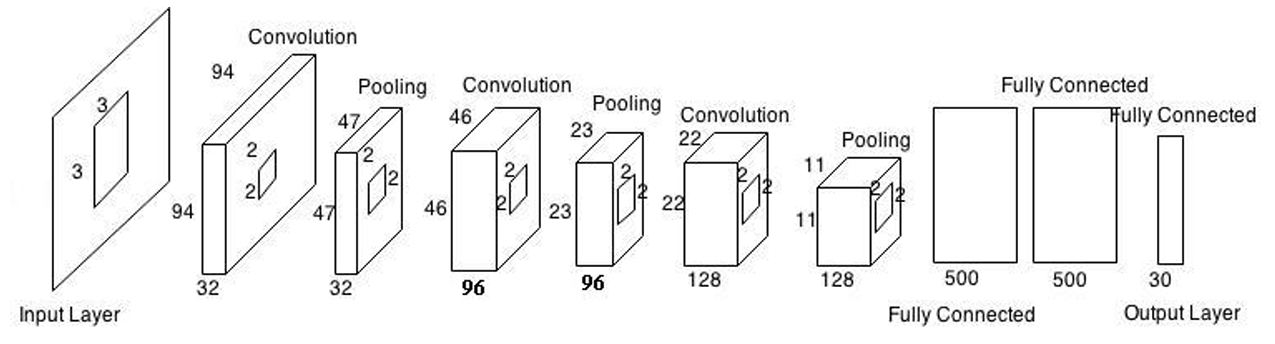

a. Có những loại lớp (layer) nào? Số lượng mỗi loại?  

b. Ảnh đầu vào có kích thước bao nhiêu?  
- Biết stride $S = 1$, số zero-padding $P = 0$  
- Ảnh màu hay ảnh xám?  

c. Lớp tích chập thứ hai:
- Có bao nhiêu kernel?  
- Kích thước mỗi kernel?  
- Tổng số tham số?  

d. Mạng có thể dùng để phân loại 35 loài động vật hay không? Tại sao?

Trả lời

a. Có những loại lớp (layer) nào? Số lượng mỗi loại? 
- nhìn vào hình vẽ thì có những lớp sau đây 
    - Input layer: 1
    - Convolution layer: 3
    - Pooling layer: 3
    - Fully Connected: 2
    - Output layer: 1

b. Ảnh đầu vào có kích thước bao nhiêu?  
- Ảnh đầu vào là **96 x 96**
- Biết stride $S = 1$, số zero-padding $P = 0$  
- Ảnh màu hay ảnh xám?  
    - Ảnh này là ảnh xám

c. Lớp tích chập thứ hai:
- Có bao nhiêu kernel? 
    - 96 kernel
- Kích thước mỗi kernel?  
    - **2x2x32**
- Tổng số tham số?  
    - Mỗi kernel có **2x2x32 = 128** cộng thêm 1 bias **128 + 1 =129** Tổng có **96 x 129 = 12384**

d. Mạng có thể dùng để phân loại 35 loài động vật hay không? Tại sao?
- Không phân loại được 35 lớp vì output hiện chỉ có 30 neuron

## Bài 8 (1 điểm)

Cho mạng CNN thỏa:

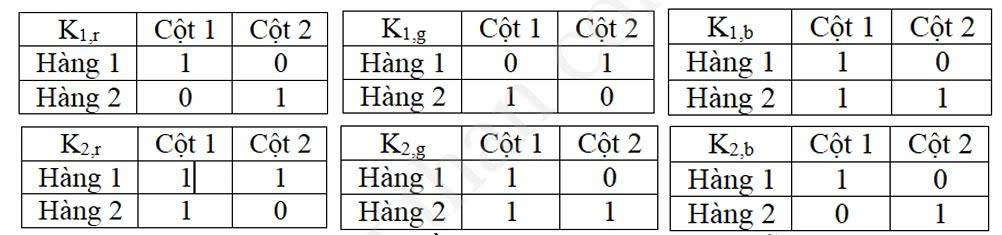

- Lớp đầu tiên là convolution
- Stride $S = 1$, zero-padding $P = 0$
- Có 2 kernel $K_1, K_2$

Ngõ vào $I$ của mạng CNN là:
- Ảnh màu gồm 3 kênh $I_r, I_g, I_b$
- Mỗi kênh kích thước $3 \times 3$

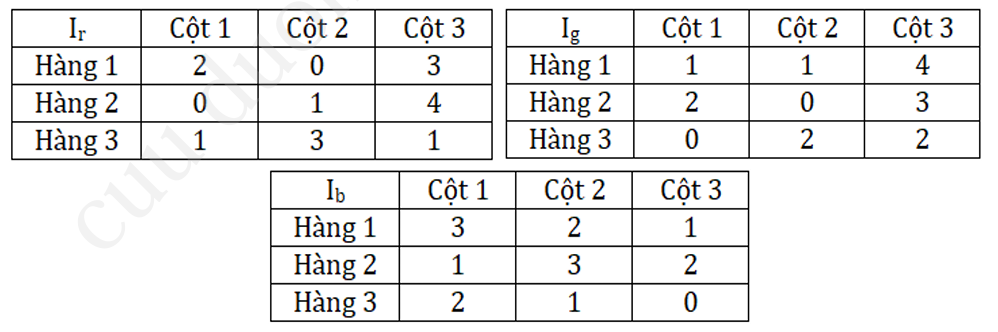

Yêu cầu:
- Xác định các activation map, biết mạng sử dụng hàm ReLU và $bias_1 = -14$, $bias_2 = -10$

> Lưu ý: Có thể tự đưa thêm giả thiết nếu cần.

In [15]:
import numpy as np


# 1) INPUT RGB (3x3x3)

Ir = np.array([
    [2, 0, 3],
    [0, 1, 4],
    [1, 3, 1]
])

Ig = np.array([
    [1, 1, 4],
    [2, 0, 3],
    [0, 2, 2]
])

Ib = np.array([
    [3, 2, 1],
    [1, 3, 2],
    [2, 1, 0]
])

# 2) KERNEL K1
K1r = np.array([
    [1, 0],
    [0, 1]
])

K1g = np.array([
    [0, 1],
    [1, 0]
])

K1b = np.array([
    [1, 0],
    [1, 1]
])

# 3) KERNEL K2
K2r = np.array([
    [1, 1],
    [1, 0]
])

K2g = np.array([
    [1, 0],
    [1, 1]
])

K2b = np.array([
    [1, 0],
    [0, 1]
])

# Bias
b1 = -14
b2 = -10

# 4) HÀM CONVOLUTION
def conv_multi_channel(Ir, Ig, Ib, Kr, Kg, Kb, bias):
    h, w = Ir.shape
    fh, fw = Kr.shape

    out_h = h - fh + 1
    out_w = w - fw + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            region_r = Ir[i:i+fh, j:j+fw]
            region_g = Ig[i:i+fh, j:j+fw]
            region_b = Ib[i:i+fh, j:j+fw]

            value = (
                np.sum(region_r * Kr) +
                np.sum(region_g * Kg) +
                np.sum(region_b * Kb) +
                bias
            )

            # ReLU
            output[i, j] = max(0, value)

    return output

# 5) TÍNH 2 FEATURE MAPS
A1 = conv_multi_channel(Ir, Ig, Ib, K1r, K1g, K1b, b1)
A2 = conv_multi_channel(Ir, Ig, Ib, K2r, K2g, K2b, b2)

print("Feature map A1:")
print(A1)

print("\nFeature map A2:")
print(A2)

Feature map A1:
[[0. 1.]
 [0. 0.]]

Feature map A2:
[[1. 2.]
 [0. 5.]]
